In [36]:
!pip install seaborn matplotlib scanpy numpy igraph harmonypy anndata==0.10.9

In [37]:
import os
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import harmonypy
import anndata

In [38]:
print(sc.__version__)
print(harmonypy.__version__)
import importlib.metadata
print(importlib.metadata.version('anndata'))

1.12.1
2.0.0
0.10.9


/tmp/ipykernel_35760/9881393.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [39]:
# -- Mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [40]:
# -- Paths
input_path = "/content/drive/MyDrive/endo-immune-atlas/data/processed/GSE179640_qc.h5ad"
output_path_data = "/content/drive/MyDrive/endo-immune-atlas/data/processed"
output_path_figures = "/content/drive/MyDrive/endo-immune-atlas/results/preprocessing"

os.makedirs(output_path_figures, exist_ok=True)


In [41]:
# -- Set palettes
patient_colors_list = [
    sns.husl_palette(n_colors=1, h=h, s=0.9, l=0.65).as_hex()[0]
    for h in np.linspace(0.01, 0.70, 14)
]

# map to patient IDs
patient_ids = ["C01", "C02", "C03",
               "E01", "E02", "E03", "E04", "E05",
               "E06", "E07", "E08", "E09", "E10", "E11"]

patient_palette = dict(zip(patient_ids, patient_colors_list))

tissue_palette = {
    "Ctrl": "#7FA25C",
    "EuE":  "#028090",
    "EcP":  "#456990",
    "EcO":  "#CE7DA5"
}

In [42]:
combined = sc.read_h5ad(input_path)
combined

AnnData object with n_obs × n_vars = 94891 × 30907
    obs: 'sample_id', 'patient_id', 'tissue_type', 'condition', 'lesion_site', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'outlier_mt', 'doublet_score', 'predicted_doublet'
    var: 'hemos', 'ribos', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet'

In [43]:
# -- Normalize counts
sc.pp.normalize_total(combined)
sc.pp.log1p(combined)

In [44]:
# -- Select HVGs
sc.pp.highly_variable_genes(combined, n_top_genes=2000, batch_key="sample_id")

sc.pl.highly_variable_genes(combined, show = False)
plt.savefig(
    os.path.join(output_path_figures, "03_integration_hvgs.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()


combined = combined[:, combined.var["highly_variable"]].copy()

In [45]:
# -- Dimensionality Reduction
sc.tl.pca(combined)
sc.pl.pca_variance_ratio(combined,
                         n_pcs=50,
                         log=True,
                         show = False)

plt.savefig(
    os.path.join(output_path_figures, "03_integration_variance_ratios.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

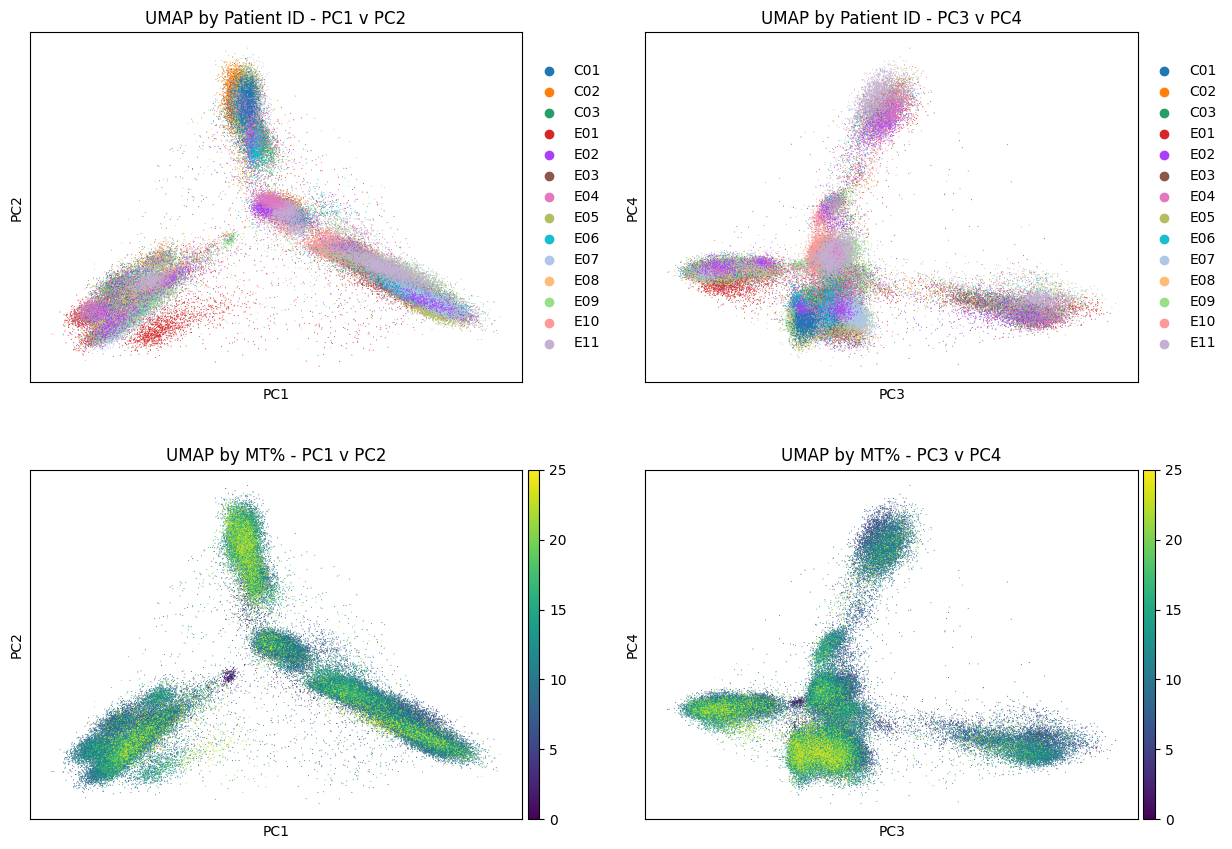

In [46]:
sc.pl.pca(
    combined,
    color=["patient_id", "patient_id", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
    title = ["UMAP by Patient ID - PC1 v PC2", "UMAP by Patient ID - PC3 v PC4", "UMAP by MT% - PC1 v PC2","UMAP by MT% - PC3 v PC4"]
)

In [ ]:
ho = harmonypy.run_harmony(
    combined.obsm["X_pca"],
    combined.obs,
    "sample_id"
)

combined.obsm["X_pca_harmony"] = ho.Z_corr

2026-06-10 04:11:03,976 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-06-10 04:11:03,977 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-06-10 04:11:03,978 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-06-10 04:11:03,980 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-06-10 04:11:03,981 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-06-10 04:11:03,982 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-06-10 04:11:03,984 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-06-10 04:11:03,985 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-06-10 04:11:03,986 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-06-10 04:11:03,989 - harmonypy - INFO -     theta: [2. 2. 2

In [ ]:
# -- Nearest Neighbors
sc.pp.neighbors(
    combined,
    use_rep="X_pca_harmony",
    n_neighbors=15
)

In [ ]:
# -- UMAP
sc.tl.umap(combined)

In [ ]:
sc.pl.umap(
    combined,
    color="patient_id",
    palette=patient_palette,
    size = 4,
    show=False,
    title = "UMAP by Patient ID"
)

plt.savefig(
    os.path.join(output_path_figures, "03_integration_umap_patient_id.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

sc.pl.umap(
    combined,
    color="tissue_type",
    palette=tissue_palette,
    size = 4,
    show=False,
    title = "UMAP by Tissue Type"
)

plt.savefig(
    os.path.join(output_path_figures, "03_integration_umap_tissue_type.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
# -- Save integration object for integration
combined.write_h5ad(os.path.join(output_path_data, "GSE179640_integration.h5ad"))

In [ ]:
#-- Session info
#session_info.show()